## K-Mean Clustering Implementation

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [31]:
from sklearn.datasets import make_blobs

In [32]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2,random_state=21)

In [33]:
X

array([[ -4.17592606,  -9.48252245],
       [ -6.27095652,  -7.99878963],
       [  4.71751276, -10.08166287],
       ...,
       [ -9.33872067,  -2.915151  ],
       [ -7.67541448,  -4.25328243],
       [ -8.16905316,  -5.23017698]], shape=(1000, 2))

In [34]:
y

array([2, 2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2,
       2, 2, 0, 2, 2, 0, 1, 1, 1, 0, 1, 1, 2, 1, 2, 1, 1, 2, 0, 1, 0, 0,
       0, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 0, 0, 2, 1,
       2, 2, 2, 0, 0, 2, 2, 1, 1, 1, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 2, 0,
       1, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 0, 1, 1, 2, 1, 2, 1, 1, 0, 2,
       0, 1, 2, 2, 2, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 2, 1, 1, 1, 1, 0, 0,
       0, 1, 2, 0, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 2, 2, 2, 1,
       0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 1, 2, 0, 1, 1, 0, 1, 2, 2, 0, 2, 0,
       2, 1, 2, 0, 1, 0, 2, 1, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       0, 0, 0, 2, 2, 2, 2, 1, 1, 0, 2, 2, 0, 1, 1, 1, 1, 1, 2, 1, 1, 0,
       2, 0, 1, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1, 0,
       1, 0, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 1,
       0, 1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 0, 1, 0, 2, 1, 2, 0, 1, 1, 2, 1,
       2, 0, 0, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 0, 0,

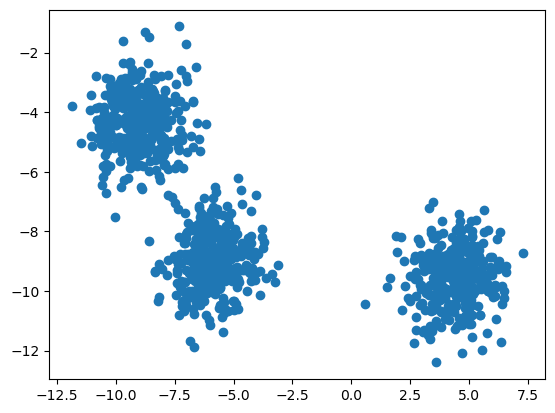

In [35]:
plt.scatter(X[:,0], X[:,1])

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=21)

In [37]:
x_train.shape

(670, 2)

In [38]:
from sklearn.cluster import KMeans

In [39]:
# Elbow method to select import k value
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [40]:
wcss

[26903.263500578432,
 4765.808382254448,
 1350.6037677913348,
 1223.6595708301486,
 1010.4553486523414,
 936.1423787506764,
 834.506719793738,
 671.41853418239,
 623.7821149338193,
 534.7821735430806]

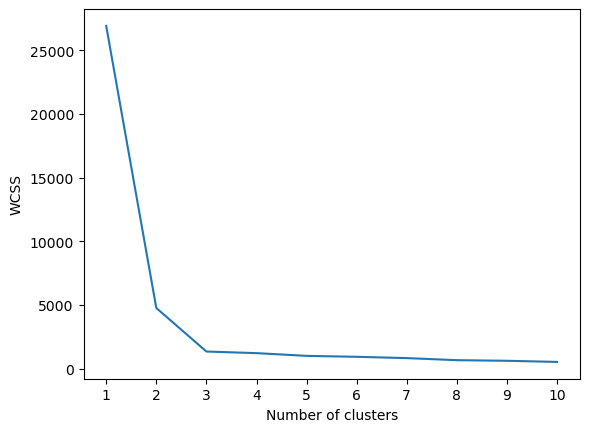

In [41]:
#  plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [42]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [43]:
y_labels = kmeans.fit_predict(x_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


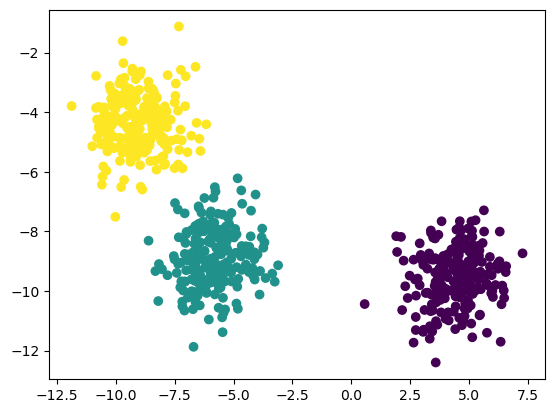

In [44]:
plt.scatter(x_train[:,0],x_train[:,1], c=y_labels)

In [45]:
#  knee locator
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [46]:
from kneed import KneeLocator

In [47]:
k1 = KneeLocator(range(1,11),wcss, curve='convex',direction='decreasing')

In [48]:
k1.elbow

np.int64(3)

In [49]:
from sklearn.metrics import silhouette_score

In [50]:
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit(x_train)
score =silhouette_score(x_train, kmeans.labels_)
print(score)

0.7283085338993158


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
